# Queue Statistics – Plots

In [ ]:
import stata_setup
stata_setup.config('/home/yichen', 'mp')


  ___  ____  ____  ____  ____ ®
 /__    /   ____/   /   ____/      StataNow 19.5
___/   /   /___/   /   /___/       MP—Parallel Edition

 Statistics and Data Science       Copyright 1985-2025 StataCorp LLC
                                   StataCorp
                                   4905 Lakeway Drive
                                   College Station, Texas 77845 USA
                                   800-782-8272        https://www.stata.com
                                   979-696-4600        service@stata.com

Stata license: Unlimited-user 2-core network, expiring 31 Oct 2026
Serial number: 501909305069
  Licensed to: Yichen Luo
               University College London

Notes:
      1. Unicode is supported; see help unicode_advice.
      2. More than 2 billion observations are allowed; see help obs_advice.
      3. Maximum number of variables is set to 5,000 but can be increased;
          see help set_maxvar.


In [ ]:
%%stata

clear all
set more off

global PROCESSED_DATA "../../processed_data"
global FIGURES        "../../lido-bank/figures"


. 
. clear all

. set more off

. 
. global PROCESSED_DATA "../../processed_data"

. global FIGURES        "../../lido-bank/figures"

. 



. ****************************
. * Queue Length Over Time
. ****************************
. 
. import delimited using "$PROCESSED_DATA/queue_daily.csv", varnames(1) clear
(encoding automatically selected: ISO-8859-1)
(7 vars, 1,057 obs)

. gen date2 = date(date, "YMD")

. format date2 %td

. 
. twoway ///
>     (line queue_length date2, lcolor(navy) lwidth(medthick)) ///
>     , ///
>     xtitle("") ///
>     ytitle("Number of Requests") ///
>     title("Lido Withdrawal Queue Length") ///
>     xlabel(, format(%tdMon-CCYY) angle(45)) ///
>     graphregion(color(white)) ///
>     plotregion(margin(zero))



. 
. graph export "$FIGURES/queue_length.pdf", replace
file ../../lido-bank/figures/queue_length.pdf saved as PDF format

. 


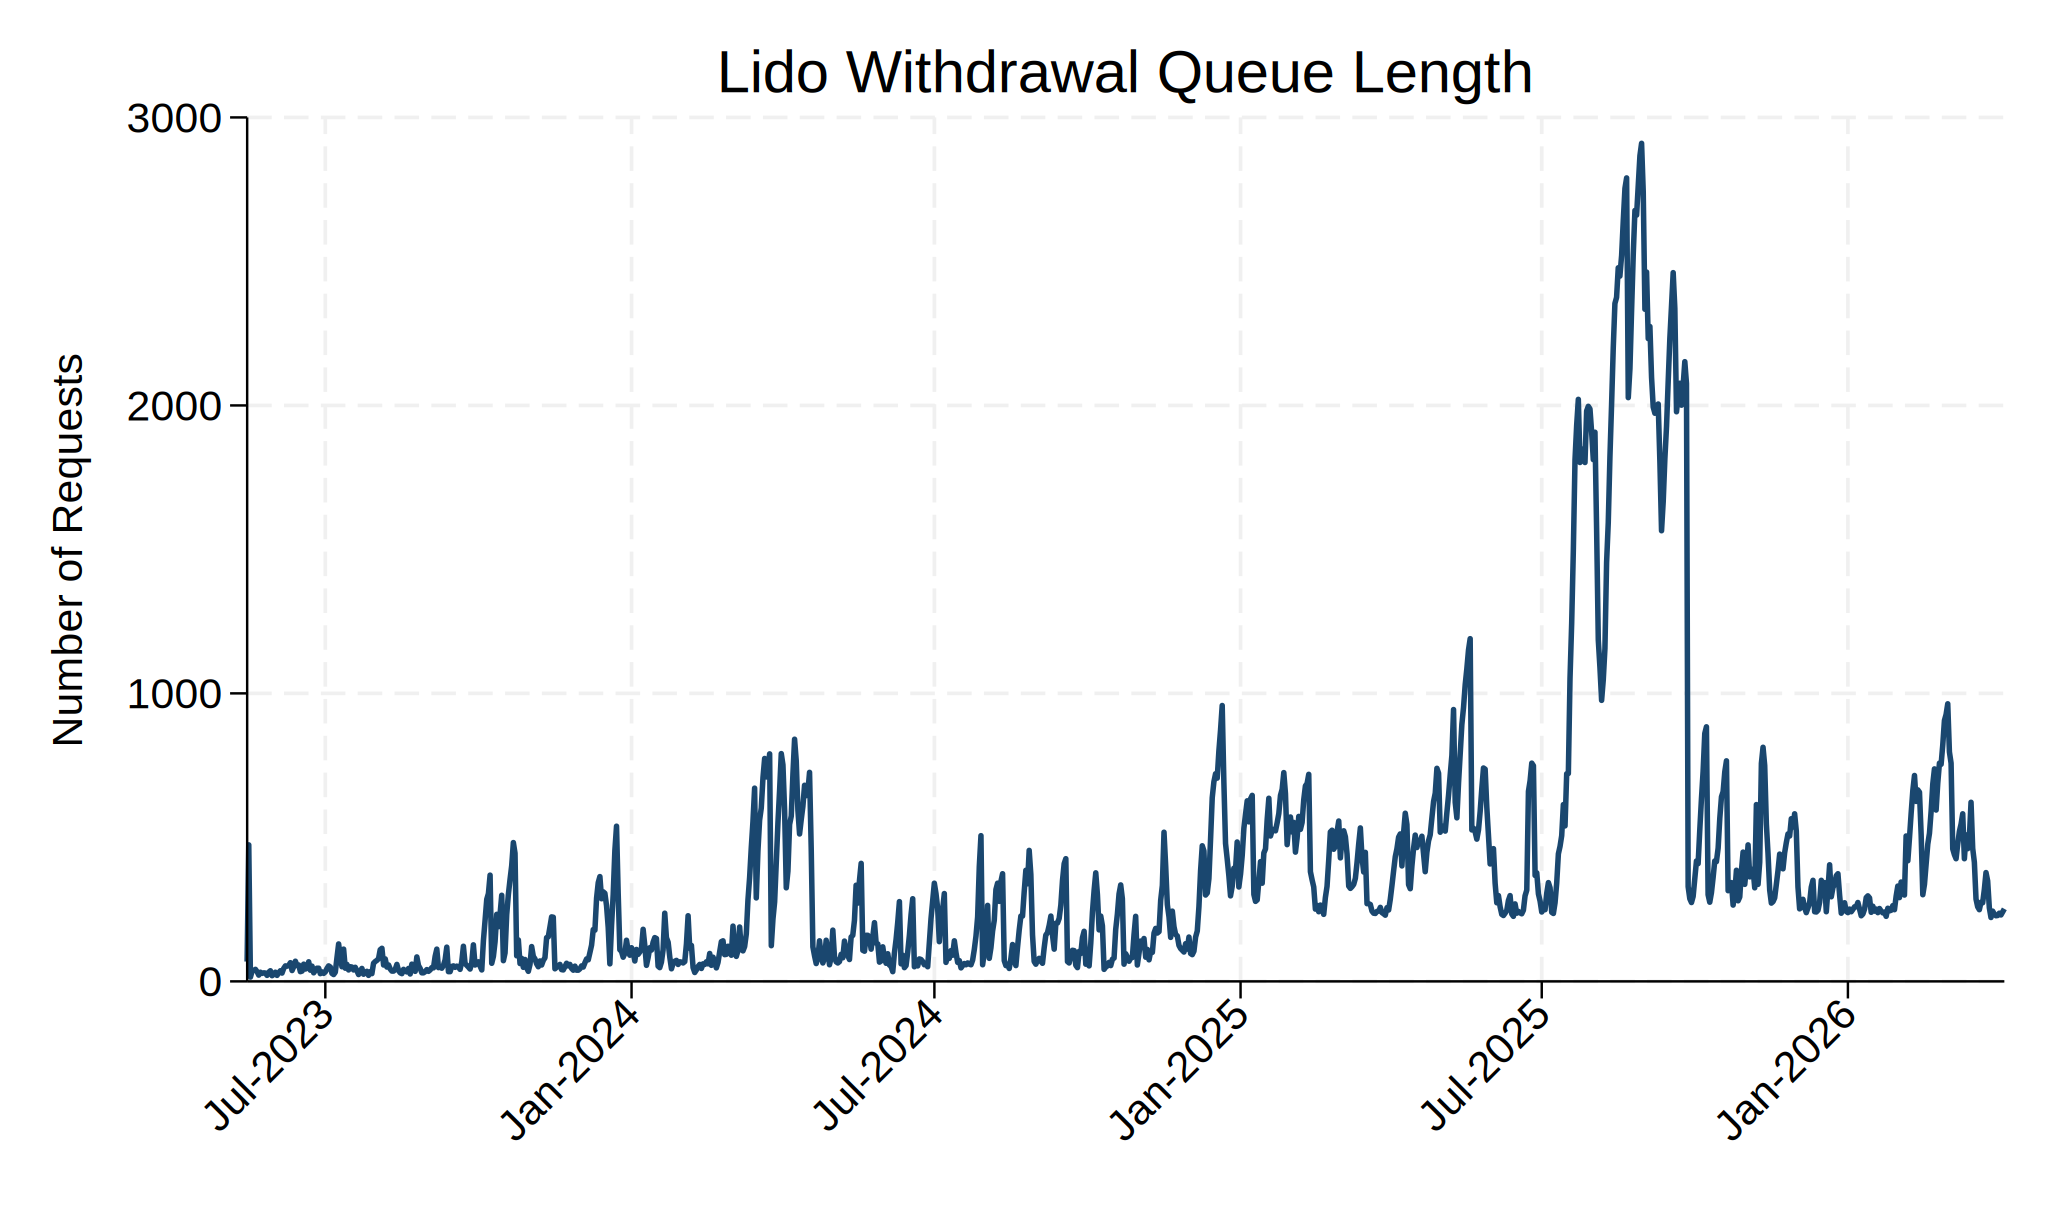

In [ ]:
%%stata
****************************
* Queue Length Over Time
****************************

import delimited using "$PROCESSED_DATA/queue_daily.csv", varnames(1) clear
gen date2 = date(date, "YMD")
format date2 %td

twoway ///
    (line queue_length date2, lcolor(navy) lwidth(medthick)) ///
    , ///
    xtitle("") ///
    ytitle("Number of Requests") ///
    title("Lido Withdrawal Queue Length") ///
    xlabel(, format(%tdMon-CCYY) angle(45)) ///
    graphregion(color(white)) ///
    plotregion(margin(zero))

graph export "$FIGURES/queue_length.pdf", replace

In [ ]:
%%stata
****************************
* Queue stETH Over Time
****************************

import delimited using "$PROCESSED_DATA/queue_daily.csv", varnames(1) clear
gen date2 = date(date, "YMD")
format date2 %td
gen queue_steth_k = queue_steth / 1000

twoway ///
    (line queue_steth_k date2, lcolor(orange) lwidth(medthick)) ///
    , ///
    xtitle("") ///
    ytitle("stETH (thousands)") ///
    title("Lido Withdrawal Queue - stETH Amount") ///
    xlabel(, format(%tdMon-CCYY) angle(45)) ///
    graphregion(color(white)) ///
    plotregion(margin(zero))

graph export "$FIGURES/queue_steth.pdf", replace


. ****************************
. * Wait Time Distribution (histogram)
. ****************************
. 
. import delimited using "$PROCESSED_DATA/queue_requests.csv", varnames(1) clea
> r
(encoding automatically selected: ISO-8859-1)


(12 vars, 119,673 obs)

. keep if is_finalized == 1
(252 observations deleted)

. 
. histogram wait_days, ///
>     width(0.5) ///
>     fcolor(navy%70) lcolor(white) lwidth(vthin) ///
>     xtitle("Days from Request to Finalization") ///
>     ytitle("Density") ///
>     title("Redemption Wait Time Distribution") ///
>     graphregion(color(white))
(bin=34, start=.10777777, width=.5)

. 
. graph export "$FIGURES/wait_time_hist.pdf", replace
file ../../lido-bank/figures/wait_time_hist.pdf saved as PDF format

. 


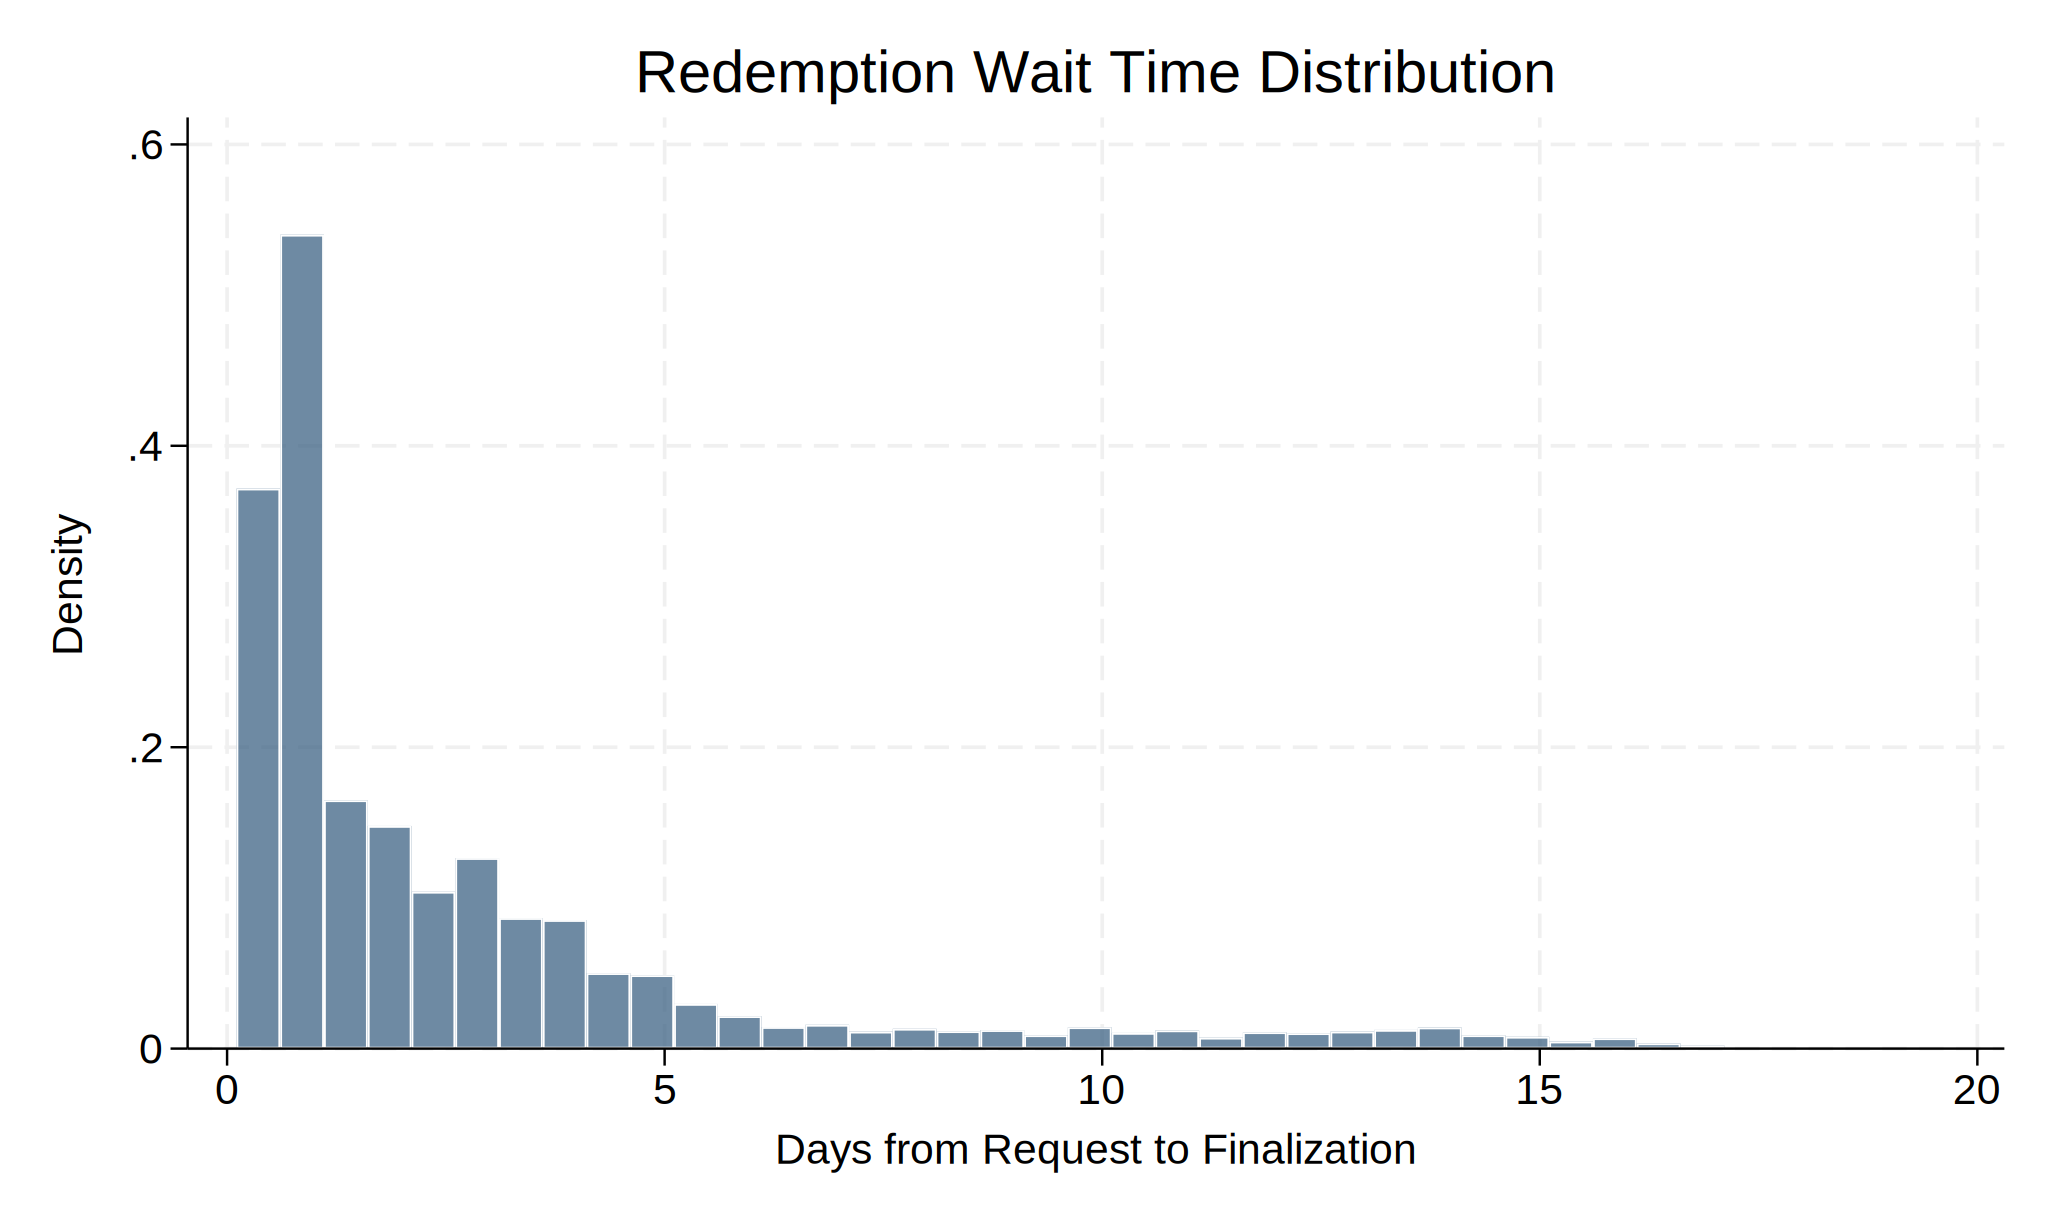

In [ ]:
%%stata
****************************
* Wait Time Distribution (histogram)
****************************

import delimited using "$PROCESSED_DATA/queue_requests.csv", varnames(1) clear
keep if is_finalized == 1

histogram wait_days, ///
    width(0.5) ///
    fcolor(navy%70) lcolor(white) lwidth(vthin) ///
    xtitle("Days from Request to Finalization") ///
    ytitle("Density") ///
    title("Redemption Wait Time Distribution") ///
    graphregion(color(white))

graph export "$FIGURES/wait_time_hist.pdf", replace

In [ ]:
%%stata
****************************
* Monthly Median Wait Time
****************************

import delimited using "$PROCESSED_DATA/queue_requests.csv", varnames(1) clear
keep if is_finalized == 1
gen submit_date2 = date(submit_date, "YMD")
format submit_date2 %td
gen month = mofd(submit_date2)
format month %tm

collapse (median) med_wait=wait_days (p25) p25_wait=wait_days (p75) p75_wait=wait_days, by(month)

twoway ///
    (rarea p25_wait p75_wait month, color(navy%25) lcolor(navy%25)) ///
    (line  med_wait month, lcolor(navy) lwidth(medthick)) ///
    , ///
    xtitle("") ///
    ytitle("Days") ///
    title("Monthly Median Redemption Wait Time") ///
    subtitle("Shaded band: 25th-75th percentile") ///
    xlabel(, format(%tmMon-CCYY) angle(45)) ///
    legend(off) ///
    graphregion(color(white))

graph export "$FIGURES/wait_time_monthly.pdf", replace